# 🧩 Ejercicios – Regresión Lineal y Estimación de Parámetros

## 🎯 Objetivo:
Explorar técnicas de **regresión lineal**, **regresión polinómica** y **ajuste de curvas**  
aplicadas a datos simulados y reales. Evaluar la **bondad del ajuste** mediante el análisis de residuos y el cálculo del **χ² reducido**.


https://scikit-learn.org/stable/
---

## 🔧 Paso 1 – Simular un conjunto de datos con ruido

Generaremos un conjunto de datos con una tendencia lineal y le agregaremos ruido gaussiano.

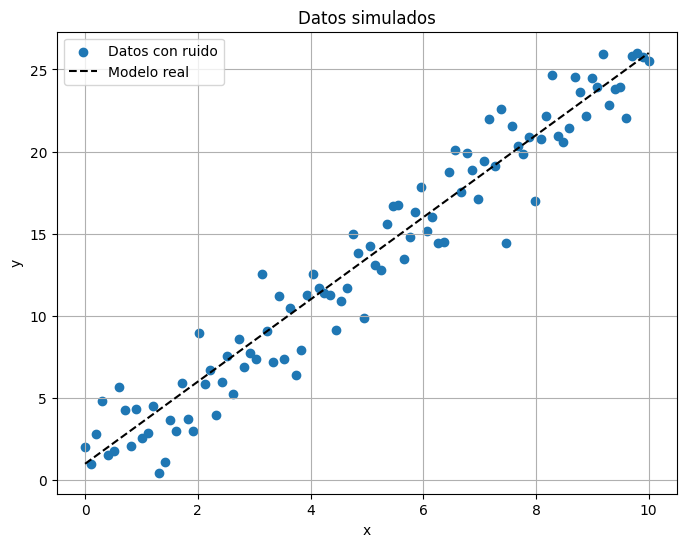

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Datos simulados
x = np.linspace(0, 10, 100)
y_true = 2.5 * x + 1.0
noise = np.random.normal(0, 2, size=x.shape)
y = y_true + noise

plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Datos con ruido')
plt.plot(x, y_true, label='Modelo real', color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos simulados')
plt.legend()
plt.grid(True)
plt.show()


## 🤖 Paso 2 – Ajuste lineal con numpy.polyfit

In [ ]:
# Ajuste lineal (grado 1)
coeffs = np.polyfit(x, y, 1)
y_fit = np.polyval(coeffs, x)

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Datos')
plt.plot(x, y_fit, color='red', label=f'Ajuste lineal: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajuste lineal por mínimos cuadrados')
plt.legend()
plt.grid(True)
plt.show()


## 📏 Paso 3 – Análisis de residuos y cálculo de χ² reducido

In [ ]:
residuals = y - y_fit
sigma2 = np.var(residuals)
chi2 = np.sum((residuals**2) / sigma2)
dof = len(x) - len(coeffs)
chi2_red = chi2 / dof

print(f"χ² reducido = {chi2_red:.2f}")

# Visualizar residuos
plt.figure(figsize=(8,4))
plt.axhline(0, color='gray', linestyle='--')
plt.scatter(x, residuals, color='purple')
plt.xlabel('x')
plt.ylabel('Residuo')
plt.title('Residuos del ajuste')
plt.grid(True)
plt.show()


## 🧩 Plantilla – Prueba con polinomios de grado n o funciones definidas

In [ ]:
from numpy.polynomial.polynomial import Polynomial

# Probar ajuste con grado variable
grado = 2  # cambia este valor a 1, 2, 3...
pfit = np.polyfit(x, y, grado)
y_model = np.polyval(pfit, x)

plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Datos')
plt.plot(x, y_model, label=f'Polinomio grado {grado}', color='orange')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Ajuste polinomial grado {grado}')
plt.grid(True)
plt.legend()
plt.show()


# Ejercicio: Ajuste de una Curva de Luz con Regresión No Lineal

**Objetivo:**  
Aplicar técnicas de regresión no lineal para ajustar un modelo físico a datos simulados de la curva de luz de una estrella pulsante.


## Contexto

Las estrellas variables pulsantes, como las Cefeidas o RR Lyrae, presentan curvas de luz periódicas. Estas curvas pueden aproximarse con funciones sinusoidales que representan la variación del brillo con el tiempo.

En este ejercicio, vas a trabajar con una curva de luz **simulada** con una función seno, ruido gaussiano y algunos *outliers*. Tu objetivo será ajustar un modelo apropiado a los datos y analizar su calidad.


## Datos simulados

Se te proporciona un conjunto de observaciones \((t_i, F_i)\), donde:

- \( t_i \): tiempo (en días)
- \( F_i \): flujo relativo observado
- Los datos incluyen ruido y 2–3 valores atípicos.


## Tareas a realizar

1. **Visualización inicial**
   - Graficá los datos observados.
   - Compará visualmente con la curva original (si se provee).

2. **Definír un modelo no lineal**
   - Proponé la función:
      F(t) = A * sin(ωt + C)

      
     donde ( A): amplitud, ( Ω): frecuencia angular, ( C ): nivel base.

3. **Ajuste del modelo**
   - Usá `curve_fit` de `scipy.optimize` para ajustar el modelo a los datos.
   - Mostrá los parámetros obtenidos.
   - Graficá el modelo ajustado junto con los datos.

4. **Comparación con modelo lineal**
   - Aplicá una regresión lineal simple a los mismos datos.
   - Graficá ambos modelos y discutí por qué el modelo lineal es inadecuado.

5. **Evaluación de la bondad del ajuste**
   - Calculá el **error cuadrático medio (MSE)** para ambos modelos.
   - (Opcional) Calculá el **chi-cuadrado reducido** si asumís errores conocidos.

6. **Discusión**
   - ¿Qué modelo representa mejor los datos?
   - ¿Qué impacto tienen los outliers?
   - ¿Cómo podrías mejorar el ajuste?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
np.random.seed(1)


In [ ]:
LinearRegression?

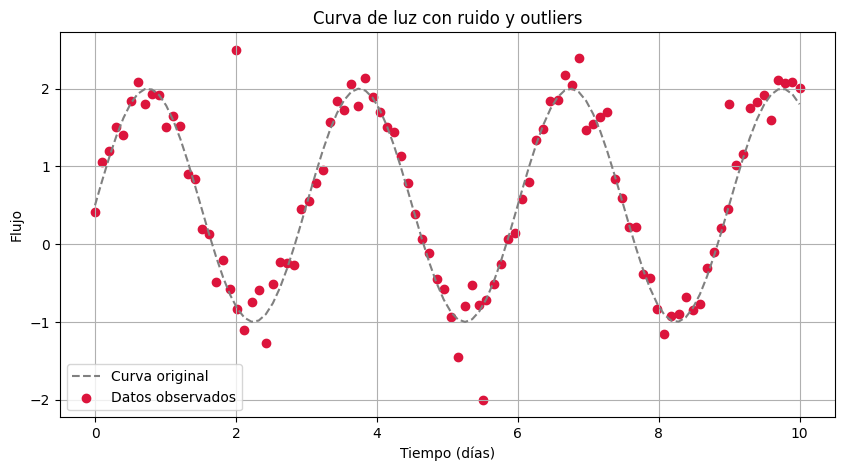

In [ ]:
time = np.linspace(0, 10, 100)
true_params = [1.5, 2*np.pi/3, 0.5]  # amplitud, frecuencia, offset
flux = true_params[0] * np.sin(true_params[1] * time) + true_params[2]
flux_noise = flux + np.random.normal(0, 0.2, size=time.shape)

# Insertamos outliers
time_out = np.append(time, [2, 5.5, 9])
flux_out = np.append(flux_noise, [2.5, -2.0, 1.8])

plt.figure(figsize=(10, 5))
plt.plot(time, flux, '--', color='gray', label="Curva original")
plt.scatter(time_out, flux_out, color='crimson', label="Datos observados")
plt.xlabel("Tiempo (días)")
plt.ylabel("Flujo")
plt.title("Curva de luz con ruido y outliers")
plt.legend()
plt.grid()
plt.show()
